# Enformer Capacity-Utilization Analysis (Measurement Phase)

Forward-hook analysis of pretrained Enformer (`EleutherAI/enformer-official-rough`) for a
sparsification study. **fp32 throughout, MPS, hooks only** (architecture untouched).

All logic lives in `enformer_capacity.py` so the same collection + figure code can be
pointed at **Borzoi** later via a different `ModelSpec` + loader.

Steps: (1) setup + CPU/MPS sanity, (2) hg38 windows, (3) hooks + attention monkey-patch,
(4) activity collection, (5) four figures, (6) interpretation.

In [1]:
import os
os.environ.setdefault("PYTORCH_ENABLE_MPS_FALLBACK", "1")  # surface fallback as warning, not crash
import numpy as np
import torch
torch.set_grad_enabled(False)

import enformer_capacity as ec
device = ec.pick_device("mps")
device

device(type='mps')

## Step 1 - load + sanity check (CHECKPOINT)
Shapes must match; CPU/MPS agreement is judged on error **relative to peak output**
(`rtol=5e-5`), not absolute diff. The absolute max-diff (~5e-4) is benign fp32
accumulation that scales with output magnitude; relative-to-peak is ~5e-6 (human) and
~1e-5 (mouse) end-to-end (verified layer-by-layer in `investigate_divergence.py`: no
single op jumps, errors track output magnitude). Safe for aggregate capacity stats.

In [2]:
model = ec.load_enformer()
report = ec.sanity_check(model, device, rtol=5e-5)
report

[09:31:49] loading Enformer weights: EleutherAI/enformer-official-rough (downloads ~1GB on first run)
[09:31:49] loaded. parameters: 251.2M
[09:31:49] Step 1: building random test sequence (batch=1)
[09:31:49] forward pass on mps
[09:31:50]   human head shape OK: (1, 896, 5313)
[09:31:50]   mouse head shape OK: (1, 896, 1643)
[09:31:50] forward pass on cpu (for agreement check)
[09:31:56]   human: max|cpu-mps|=5.627e-04 mean=4.257e-06 rel=5.130e-06 OK
[09:31:56]   mouse: max|cpu-mps|=4.077e-04 mean=3.691e-06 rel=1.014e-05 OK


{'device': 'mps',
 'rtol': 5e-05,
 'heads': {'human': {'max_abs': 0.0005626678466796875,
   'mean_abs': 4.2574711187626235e-06,
   'rel_to_peak': 5.129814565724111e-06,
   'within_rtol': True},
  'mouse': {'max_abs': 0.0004076957702636719,
   'mean_abs': 3.6910639664711198e-06,
   'rel_to_peak': 1.0139713150716729e-05,
   'within_rtol': True}},
 'passed': True}

## Step 2 - real hg38 windows
Genome-wide 196,608 bp windows, N-heavy regions filtered. Synthetic sequence is never
used for stats (it gives misleading dead-channel rates).

In [3]:
N_WINDOWS = 64
windows = ec.sample_hg38_windows("data/hg38.fa", n_windows=N_WINDOWS, seed=0)
encoded = ec.encode_windows(windows)
len(encoded), tuple(encoded[0].shape)

[09:31:56] sampling 64 hg38 windows of 196,608 bp (max N frac 0.01)
[09:31:56]   collected 10/64 (skipped 0 N-heavy)
[09:31:56]   collected 20/64 (skipped 0 N-heavy)
[09:31:56]   collected 30/64 (skipped 0 N-heavy)
[09:31:56]   collected 40/64 (skipped 0 N-heavy)
[09:31:56]   collected 50/64 (skipped 0 N-heavy)
[09:31:56]   collected 60/64 (skipped 0 N-heavy)
[09:31:56] done: 64 windows, 0 N-heavy windows skipped


(64, (196608, 4))

## Step 3 - hooks + attention capture
`build_enformer_spec` resolves module paths: MLP intermediate = `blk[1].fn[3]` (post-ReLU,
3072-d), attention = `blk[0].fn[1]`, residual = whole block output. Attention weights are
**not** exposed by enformer-pytorch, so `install_attn_capture` **monkey-patches**
`Attention.forward` (per-instance) to stash post-softmax weights. Reused for Borzoi by
writing a new spec.

In [4]:
spec = ec.build_enformer_spec(model)
spec.name, spec.n_layers, spec.n_heads

('enformer', 11, 8)

## Step 4 - activity collection
Bounded memory: per-head attention entropy and 90%-mass fraction are reduced inside the
loop (on CPU fp64 for stable stats); no full attention matrices are retained. Start at
batch 1; raise to 2 if memory allows.

In [5]:
stats = ec.collect_activations(model, encoded, spec, device, batch_size=1)
{k: (v.shape if hasattr(v, "shape") else v) for k, v in stats.items()}

[09:31:56] collecting on 64 sequences, batch_size=1, device=mps
[09:31:59]   1/64 sequences done
[09:32:00]   2/64 sequences done
[09:32:02]   3/64 sequences done
[09:32:04]   4/64 sequences done
[09:32:06]   5/64 sequences done
[09:32:08]   6/64 sequences done
[09:32:10]   7/64 sequences done
[09:32:11]   8/64 sequences done
[09:32:13]   9/64 sequences done
[09:32:15]   10/64 sequences done
[09:32:17]   11/64 sequences done
[09:32:19]   12/64 sequences done
[09:32:21]   13/64 sequences done
[09:32:22]   14/64 sequences done
[09:32:24]   15/64 sequences done
[09:32:26]   16/64 sequences done
[09:32:28]   17/64 sequences done
[09:32:30]   18/64 sequences done
[09:32:32]   19/64 sequences done
[09:32:33]   20/64 sequences done
[09:32:35]   21/64 sequences done
[09:32:37]   22/64 sequences done
[09:32:39]   23/64 sequences done
[09:32:41]   24/64 sequences done
[09:32:43]   25/64 sequences done
[09:32:44]   26/64 sequences done
[09:32:46]   27/64 sequences done
[09:32:48]   28/64 sequence

{'name': 'enformer',
 'n_layers': 11,
 'n_heads': 8,
 'n_seqs': 64,
 'mass': 0.9,
 'attn_entropy': (11, 8),
 'attn_mass_frac': (11, 8),
 'mlp_abs_mean': (11, 3072),
 'resid_norm': (11,)}

## Step 5 - figures
Dead channel = `mean|act| < 1e-6` (ReLU activations are bimodal with a point mass at exactly
zero, so a fixed near-zero cutoff is used, not a percentile).

In [6]:
fig_meta = ec.make_figures(stats, outdir="results", dead_thresh=1e-6)
fig_meta

{'dead_threshold': 1e-06,
 'dead_per_layer': [14.778645833333334,
  14.713541666666666,
  9.147135416666668,
  7.32421875,
  5.826822916666666,
  4.296875,
  3.3854166666666665,
  2.34375,
  0.5533854166666667,
  0.13020833333333331,
  0.5859375]}

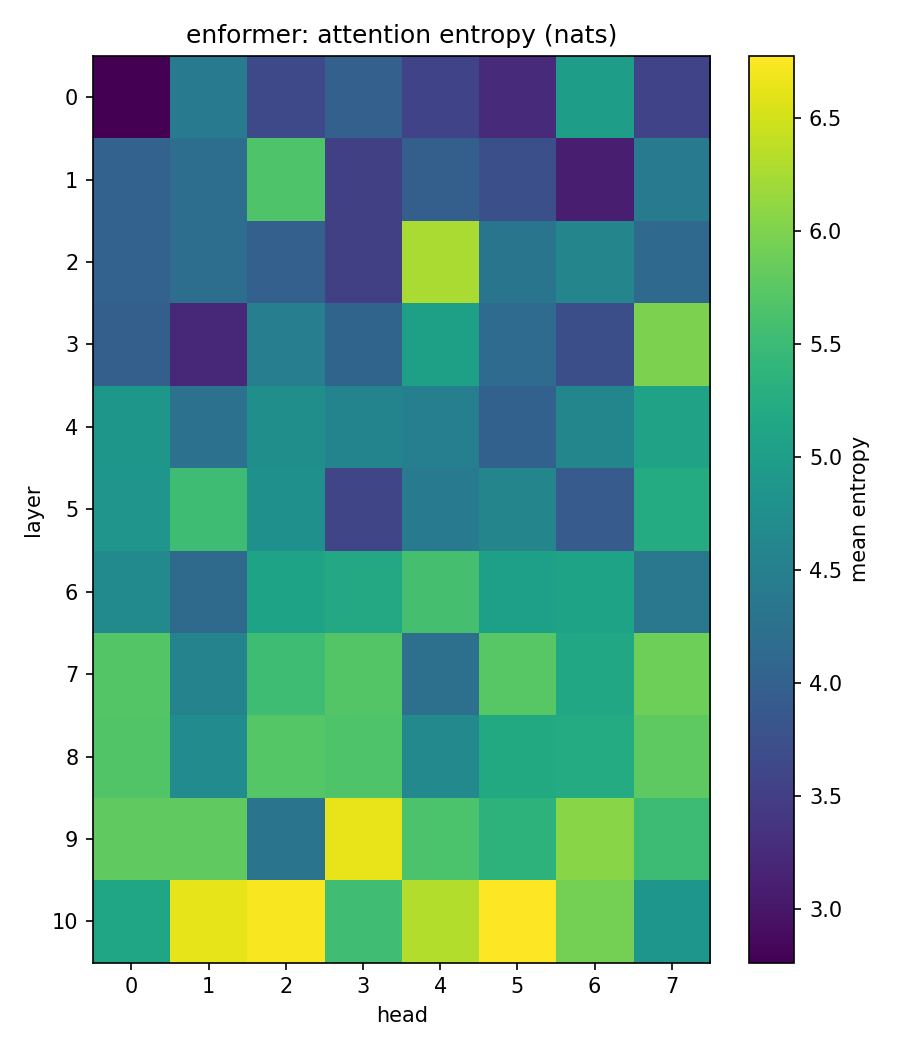

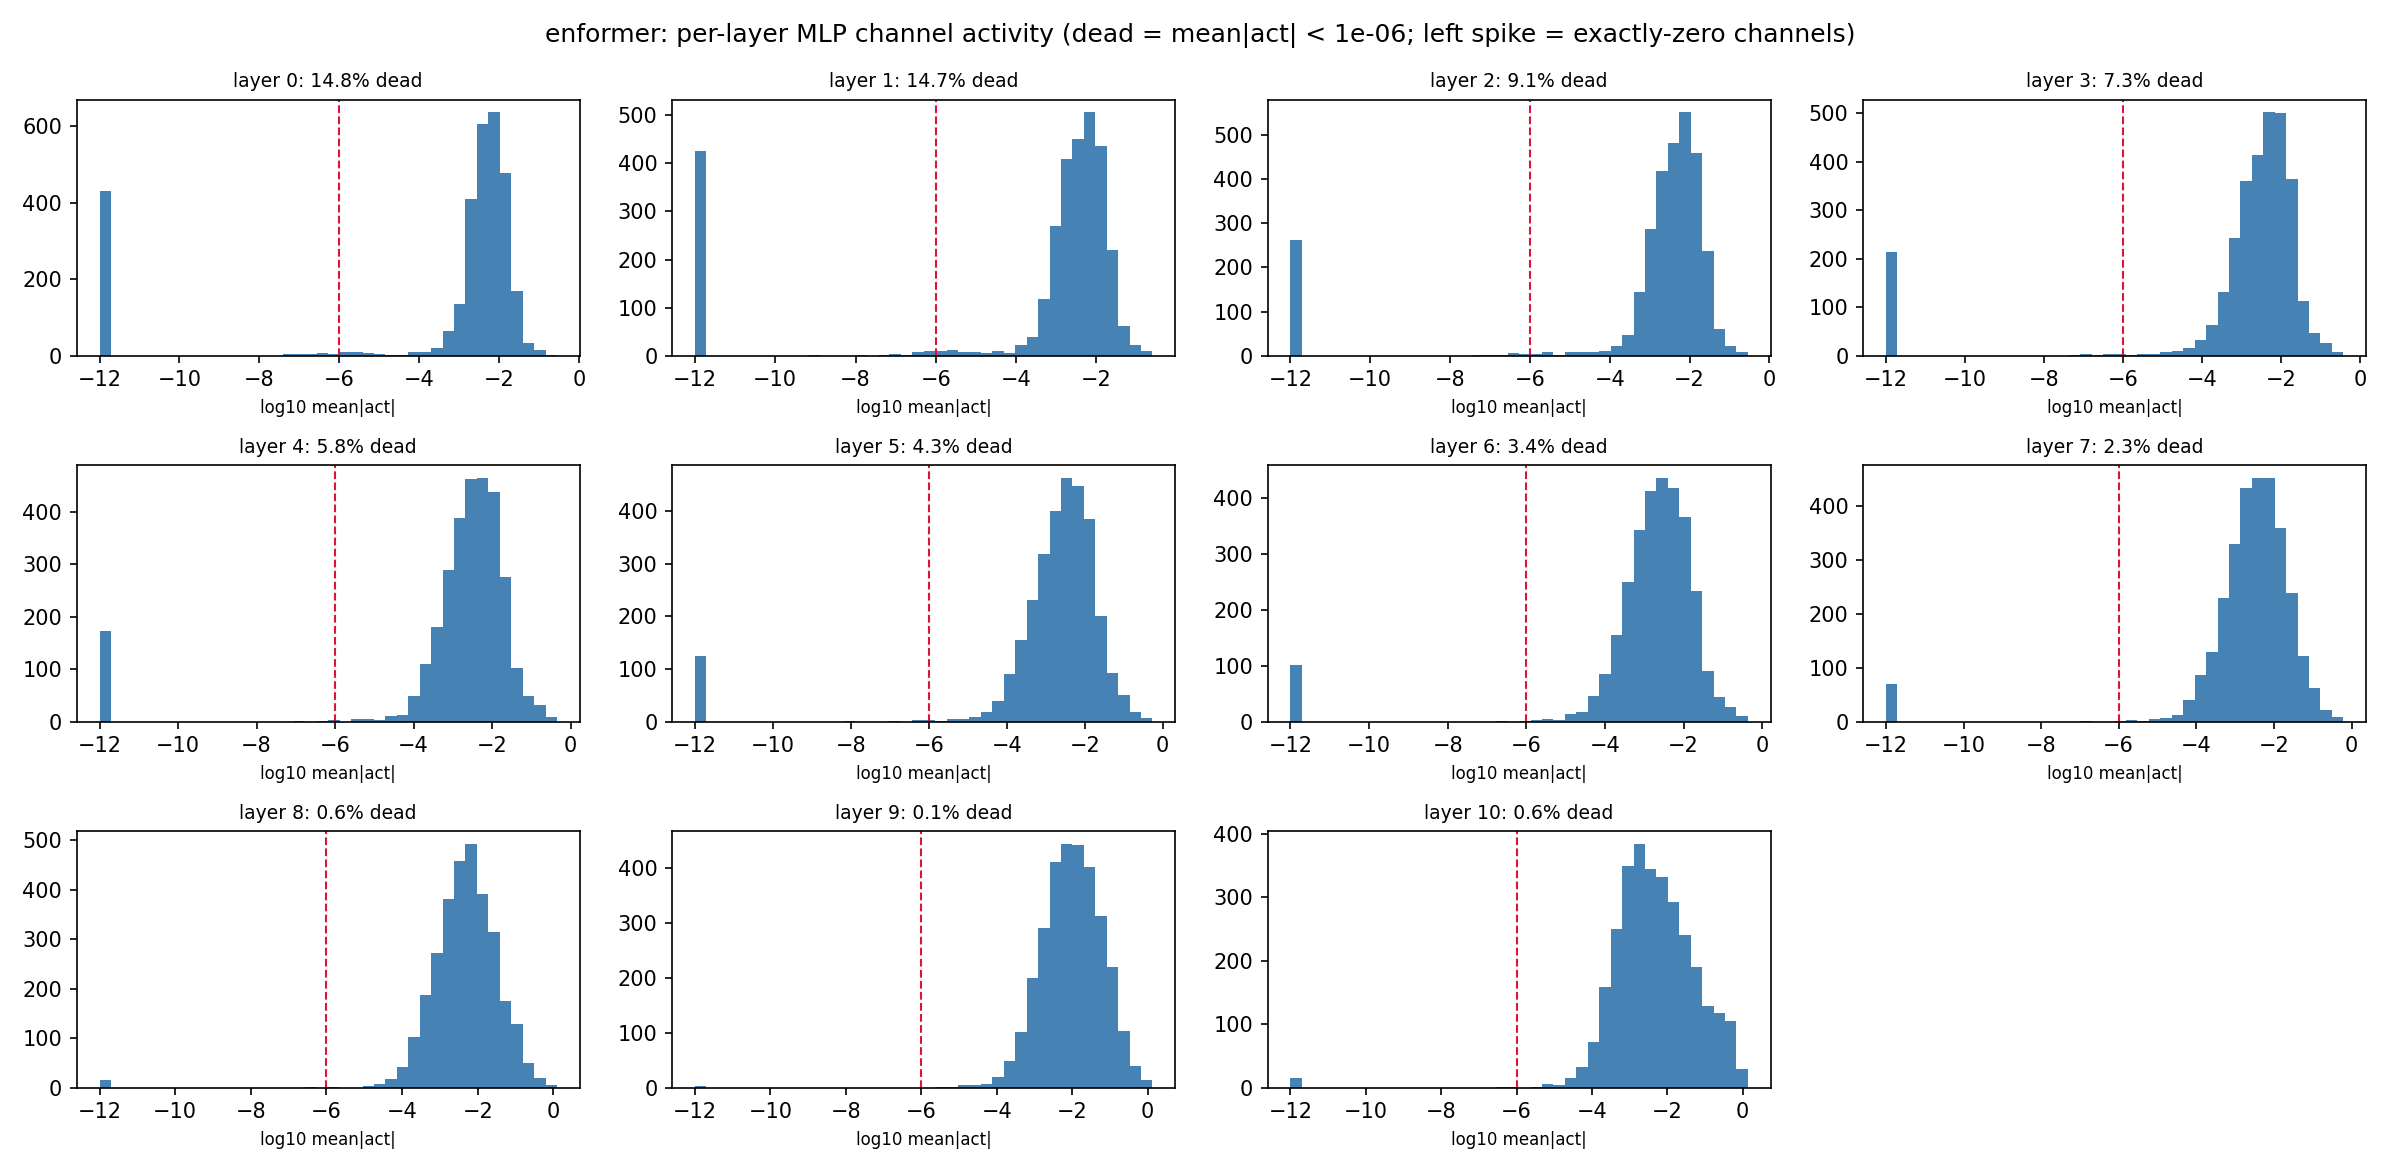

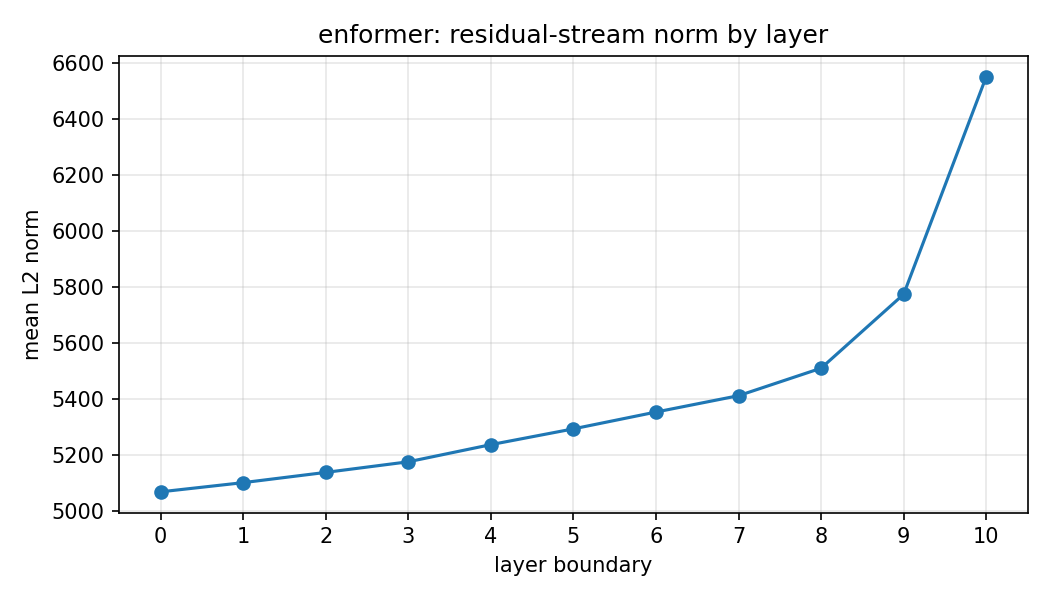

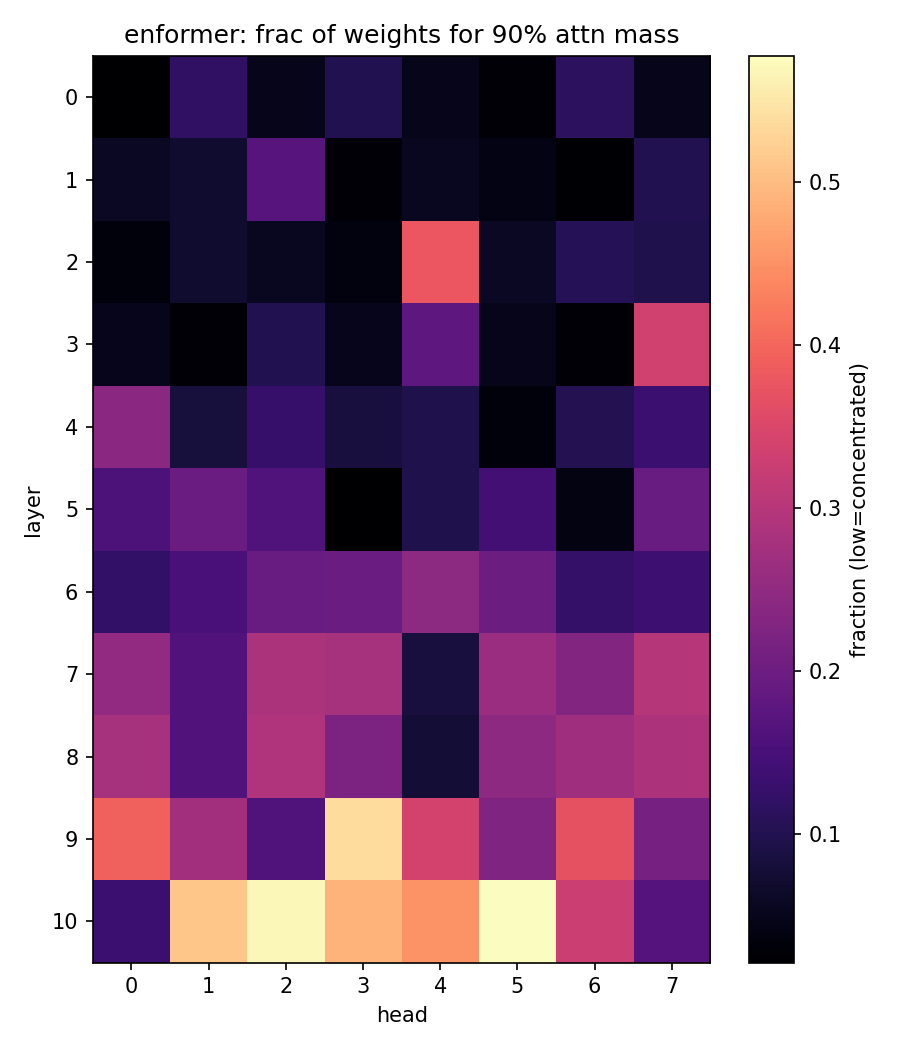

In [7]:
from IPython.display import Image, display
for f in ["01_attention_entropy", "02_dead_channels", "03_residual_norm", "04_attention_sparsity"]:
    display(Image(f"results/{f}.png"))

## Step 6 - interpretation

In [8]:
ec.write_summary(stats, fig_meta, outdir="results")

CAPACITY-UTILIZATION SUMMARY: enformer  (n_seqs=64, 11 layers x 8 heads)

[1] Attention entropy + [4] diffuseness (prune candidates)
  high-entropy AND diffuse heads (top-quartile both): 19 heads
    L 2 H4: entropy=6.264 nats, 90%-mass frac=0.380
    L 3 H7: entropy=5.986 nats, 90%-mass frac=0.335
    L 7 H0: entropy=5.694 nats, 90%-mass frac=0.250
    L 7 H3: entropy=5.706 nats, 90%-mass frac=0.279
    L 7 H5: entropy=5.737 nats, 90%-mass frac=0.263
    L 7 H7: entropy=5.888 nats, 90%-mass frac=0.299
    L 8 H0: entropy=5.686 nats, 90%-mass frac=0.279
    L 8 H2: entropy=5.722 nats, 90%-mass frac=0.291
    L 8 H7: entropy=5.779 nats, 90%-mass frac=0.287
    L 9 H0: entropy=5.799 nats, 90%-mass frac=0.392
    L 9 H1: entropy=5.788 nats, 90%-mass frac=0.272
    L 9 H3: entropy=6.645 nats, 90%-mass frac=0.538
    L 9 H4: entropy=5.633 nats, 90%-mass frac=0.340
    L 9 H6: entropy=6.060 nats, 90%-mass frac=0.370
    L10 H1: entropy=6.620 nats, 90%-mass frac=0.511
    L10 H2: entropy=6.74

## Borzoi reuse
Write `build_borzoi_spec(model)` returning a `ModelSpec` with Borzoi's module paths +
attention-capture installer, then call the **same** `collect_activations` / `make_figures` /
`write_summary`.